In [7]:
# Week 2 Part 2 - Neural Networks & Gradients for Security
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

print("✅ Ready for Neural Networks")

✅ Ready for Neural Networks


In [8]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(1, 16)   # Input → 16 neurons
        self.layer2 = nn.Linear(16, 8)   # 16 → 8 neurons
        self.layer3 = nn.Linear(8, 1)    # 8 → 1 output (price)
        self.relu = nn.ReLU()            # Activation (makes it non-linear)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

model = SimpleNet()
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters (numbers the model will learn): {total_params}")

SimpleNet(
  (layer1): Linear(in_features=1, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (layer3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)
Total parameters (numbers the model will learn): 177


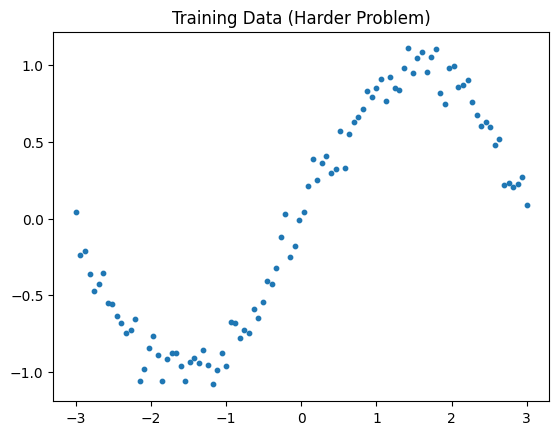

In [9]:
# Non-linear data (sine wave) - harder than straight line
X = torch.linspace(-3, 3, 100).unsqueeze(1)   # 100 points
y = torch.sin(X) + 0.1 * torch.randn_like(X)  # sine wave + noise

plt.scatter(X.numpy(), y.numpy(), s=10)
plt.title("Training Data (Harder Problem)")
plt.show()

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

losses = []

for epoch in range(1000):
    # Forward pass
    predictions = model(X)

    # Calculate loss
    loss = loss_fn(predictions, y)
    losses.append(loss.item())

    # Backward + Optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

Epoch 0: Loss = 0.6167
Epoch 200: Loss = 0.0089
Epoch 400: Loss = 0.0079
Epoch 600: Loss = 0.0071
Epoch 800: Loss = 0.0069


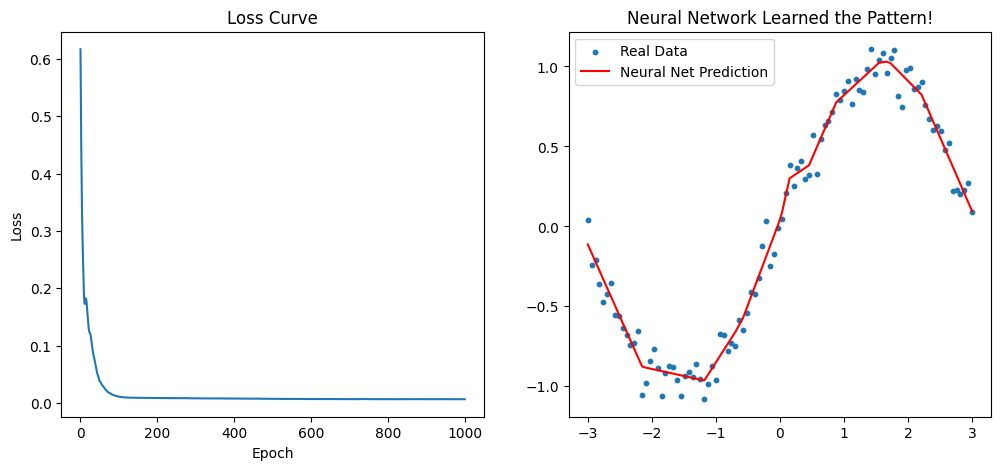

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
with torch.no_grad():
    final_pred = model(X)

plt.scatter(X.numpy(), y.numpy(), s=10, label='Real Data')
plt.plot(X.numpy(), final_pred.numpy(), 'r-', label='Neural Net Prediction')
plt.title('Neural Network Learned the Pattern!')
plt.legend()
plt.show()

In [12]:
# This is very important for later attacks
x_test = torch.tensor([[0.5]], requires_grad=True)

output = model(x_test)
loss = loss_fn(output, torch.tensor([[0.0]]))

loss.backward()

print("Gradient w.r.t Input:", x_test.grad)

print("\n=== Security Meaning ===")
print("This gradient tells us: If I change the input a little, how does the output change?")
print("In Block 2 you will use this to create adversarial examples (attacks).")

Gradient w.r.t Input: tensor([[0.7855]])

=== Security Meaning ===
This gradient tells us: If I change the input a little, how does the output change?
In Block 2 you will use this to create adversarial examples (attacks).


In [13]:
# Save model
torch.save(model.state_dict(), 'week2_model.pt')
print("✅ Model saved as week2_model.pt")

# Load it back to test
loaded_model = SimpleNet()
loaded_model.load_state_dict(torch.load('week2_model.pt'))
loaded_model.eval()

print("✅ Model loaded successfully")

✅ Model saved as week2_model.pt
✅ Model loaded successfully
